# Model Explainability for Revenue Forecasting

Machine learning models can provide highly accurate predictions, but understanding **why a model makes certain predictions** is equally important.

Model explainability helps:

- interpret model behavior
- identify the main drivers of predictions
- detect potential biases
- build trust in machine learning systems

In this notebook we apply **SHAP (SHapley Additive Explanations)** to interpret the revenue forecasting models developed in the previous notebook.

The analysis includes:

- global feature importance
- SHAP summary plots
- local prediction explanations
- business interpretation of model drivers

In [1]:
"""
Environment Setup
"""

import os
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import shap

from sklearn.ensemble import GradientBoostingRegressor

sns.set_style("whitegrid")
sns.set_context("talk")

DATA_PATH = "../data/processed"
FIG_PATH = "../figures/model_explainability"

os.makedirs(FIG_PATH, exist_ok=True)

print("Environment ready.")

Environment ready.


In [2]:
def save_plot(name):

    path = os.path.join(FIG_PATH, name)

    plt.tight_layout()

    plt.savefig(path, dpi=300)

    plt.show()

In [3]:
"""
Load Feature Dataset
"""

timeseries_features = pd.read_csv(
    f"{DATA_PATH}/model_features_timeseries.csv",
    parse_dates=["order_date"]
)

print("Dataset shape:", timeseries_features.shape)

timeseries_features.head()

Dataset shape: (672, 30)


,order_date,daily_revenue,daily_orders,year,month,day,day_of_week,week_of_year,is_weekend,month_sin,...,orders_lag_30,revenue_roll_mean_7,revenue_roll_mean_14,revenue_roll_mean_30,revenue_roll_std_7,revenue_roll_std_14,revenue_roll_std_30,orders_roll_mean_7,orders_roll_mean_14,orders_roll_mean_30
0,2023-03-01,54756.68,518,2023,3,1,2,9,0,1.0,...,542.0,59744.527143,59405.285714,58424.730000,8793.149490,7205.569421,6398.566419,556.714286,549.000000,544.300000
1,2023-03-02,53631.11,538,2023,3,2,3,9,0,1.0,...,516.0,59344.904286,59515.167143,58322.024667,9029.365176,7096.381434,6451.510746,558.857143,550.500000,545.033333
2,2023-03-03,55755.00,543,2023,3,3,4,9,0,1.0,...,519.0,59244.697143,59626.304286,58310.265667,9070.561975,7018.477464,6456.005704,559.571429,554.428571,545.833333
3,2023-03-04,78290.06,666,2023,3,4,5,9,1,1.0,...,527.0,59180.164286,60708.832143,58889.759333,8908.896605,8593.326357,7407.135727,561.000000,559.071429,550.466667
4,2023-03-05,63179.98,593,2023,3,5,6,9,1,1.0,...,488.0,59402.350000,60241.390714,59305.391333,8998.962306,8235.755848,7281.142029,552.714286,557.214286,553.966667


In [4]:
"""
Prepare Features and Target
"""

target = "daily_revenue"

X = timeseries_features.drop(
    columns=["order_date", target],
    errors="ignore"
)

X = X.select_dtypes(include=[np.number])

y = timeseries_features[target]

print("Feature matrix shape:", X.shape)

Feature matrix shape: (672, 28)


In [5]:
"""
Train Best Forecasting Model
"""

model = GradientBoostingRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=4,
    random_state=42
)

model.fit(X, y)

print("Gradient Boosting model trained.")

Gradient Boosting model trained.


In [6]:
"""
Create SHAP Sample Dataset
"""

X_sample = X.sample(
    n=300,
    random_state=42
)

print("Sample size:", X_sample.shape)

Sample size: (300, 28)


In [7]:
"""
Initialize SHAP Explainer
"""

explainer = shap.TreeExplainer(model)

shap_values = explainer.shap_values(X_sample)

print("SHAP values calculated.")

SHAP values calculated.


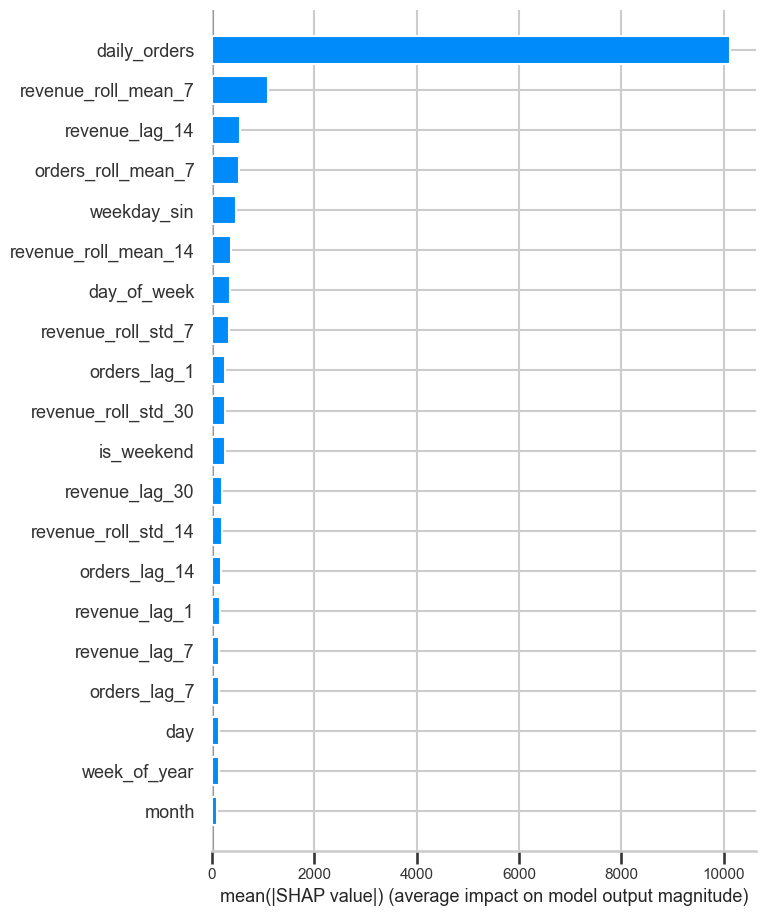

In [8]:
"""
SHAP Feature Importance
"""

shap.summary_plot(
    shap_values,
    X_sample,
    plot_type="bar",
    show=False
)

save_plot("shap_feature_importance.png")

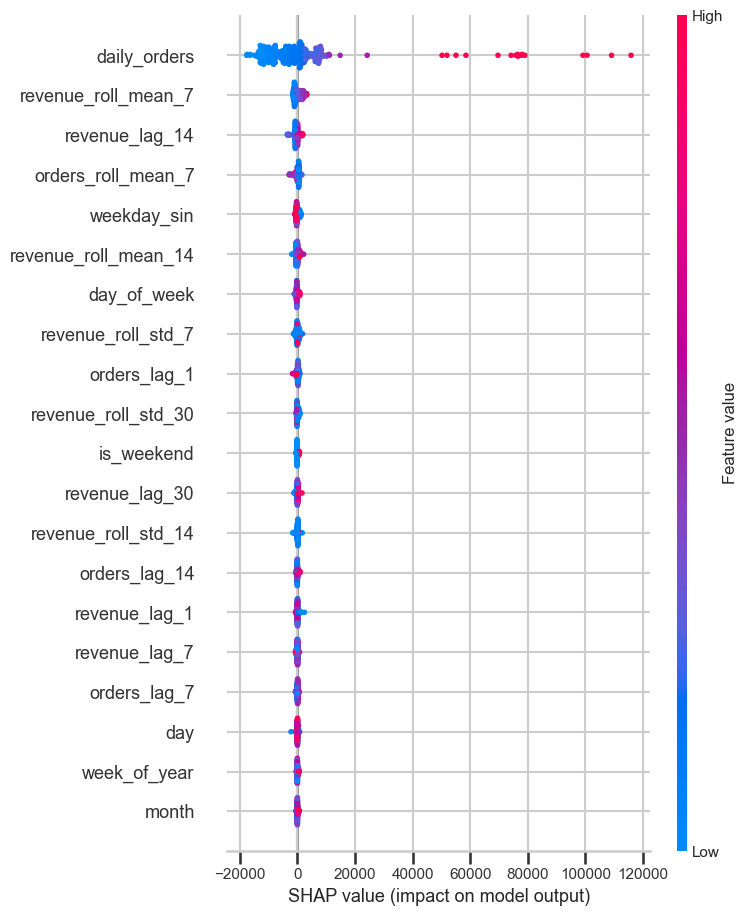

In [9]:
"""
SHAP Summary Plot
"""

shap.summary_plot(
    shap_values,
    X_sample,
    show=False
)

save_plot("shap_summary_plot.png")

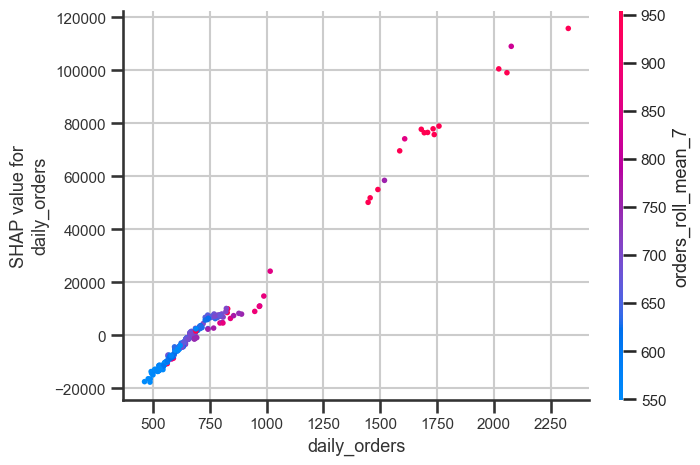

In [10]:
"""
SHAP Dependence Plot
"""

shap.dependence_plot(
    "daily_orders",
    shap_values,
    X_sample,
    show=False
)

save_plot("shap_dependence_daily_orders.png")

In [11]:
"""
Select Example Prediction
"""

example_index = 10

X_sample.iloc[example_index]

daily_orders              612.000000
year                     2023.000000
month                       5.000000
day                        21.000000
day_of_week                 6.000000
week_of_year               20.000000
is_weekend                  1.000000
month_sin                   0.500000
month_cos                  -0.866025
weekday_sin                -0.781831
weekday_cos                 0.623490
revenue_lag_1           70051.400000
revenue_lag_7           66422.550000
revenue_lag_14          78399.990000
revenue_lag_30          58978.930000
orders_lag_1              635.000000
orders_lag_7              636.000000
orders_lag_14             683.000000
orders_lag_30             509.000000
revenue_roll_mean_7     59967.842857
revenue_roll_mean_14    60004.427857
revenue_roll_mean_30    61290.686333
revenue_roll_std_7       7108.700431
revenue_roll_std_14      6401.800716
revenue_roll_std_30      7821.346365
orders_roll_mean_7        553.571429
orders_roll_mean_14       562.071429
o

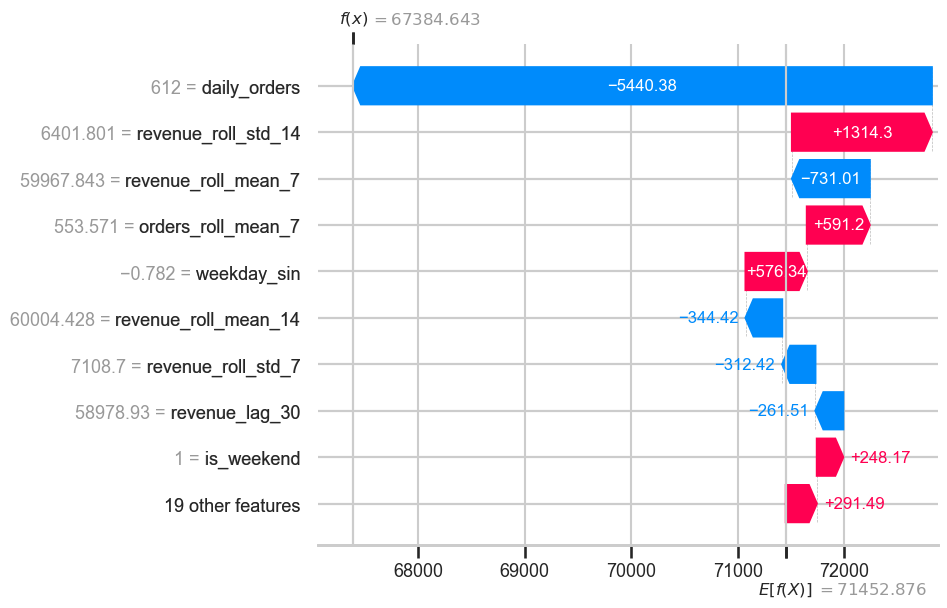

In [12]:
"""
SHAP Waterfall Plot
"""

shap.plots.waterfall(
    shap.Explanation(
        values=shap_values[example_index],
        base_values=explainer.expected_value,
        data=X_sample.iloc[example_index],
        feature_names=X_sample.columns
    )
)

In [13]:
"""
SHAP Force Plot
"""

shap.initjs()

shap.force_plot(
    explainer.expected_value,
    shap_values[example_index],
    X_sample.iloc[example_index]
)

## Explainability Insights

In this notebook we applied SHAP (SHapley Additive Explanations) to interpret the revenue forecasting model.

The explainability analysis provided insights into both global model behavior and individual predictions.

### Global Model Drivers

The SHAP feature importance analysis revealed that the most influential predictors include:

- recent order volume
- lagged revenue values
- rolling averages of past revenue
- temporal patterns such as day-of-week and seasonal effects

These variables capture both **short-term demand dynamics** and **long-term temporal patterns** in e-commerce sales.

### Local Prediction Insights

Local explanations showed how individual features contribute to specific revenue predictions.

Using waterfall and force plots, we decomposed predictions into feature-level contributions.  
This allows us to understand:

- why the model predicted a specific revenue value
- which factors increased the prediction
- which factors decreased the prediction

### Importance of Explainability

Model explainability is essential for real-world machine learning systems.

Interpretability helps organizations:

- validate model behavior
- detect potential biases
- build trust in predictive systems
- support transparent decision-making

### Final Remarks

Together with the previous notebooks, this project demonstrates a complete end-to-end data science workflow for e-commerce analytics:

- synthetic dataset generation
- exploratory data analysis
- feature engineering
- customer segmentation
- machine learning forecasting
- model explainability

This structured pipeline reflects how machine learning solutions are developed and deployed in real-world business environments.